In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 设置 DataFrame 表格打印显示格式
pd.set_option('display.max_columns', None)  # 设置最大显示列数：None代表全部列都显示
pd.set_option('display.width', 2000)        # 设置输出表格宽度，数值调大，单位字符
pd.set_option('display.max_colwidth', 30)   # 每列最大字符长度

# 查看基本信息
df = pd.read_csv("10.data.csv")
print(df.shape)
print(df.info())

(1000, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   footfall     1000 non-null   int64
 1   tempMode     1000 non-null   int64
 2   AQ           1000 non-null   int64
 3   USS          1000 non-null   int64
 4   CS           1000 non-null   int64
 5   VOC          1000 non-null   int64
 6   RP           1000 non-null   int64
 7   IP           1000 non-null   int64
 8   Temperature  1000 non-null   int64
 9   fail         1000 non-null   int64
dtypes: int64(10)
memory usage: 78.3 KB
None


=== 设备故障标签分布 ===
fail
0    0.97
1    0.03
Name: proportion, dtype: float64


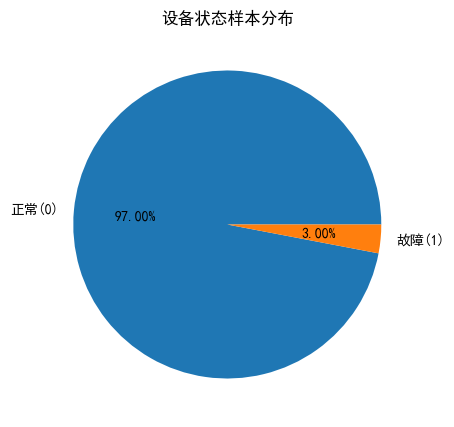

In [5]:
""" 查看标签分布 """
print("=== 设备故障标签分布 ===")
print(df['fail'].value_counts(normalize=True).round(4))

plt.figure(figsize=(5, 5))
df['fail'].value_counts().plot.pie(labels=["正常(0)", "故障(1)"], autopct='%1.2f%%')
plt.title("设备状态样本分布")
plt.ylabel("")
plt.show()

=== 正常 vs 故障 各特征均值对比 ===
      footfall  tempMode    AQ   USS    CS   VOC     RP    IP  Temperature
fail                                                                      
0       300.66      3.73  4.20  3.04  5.28  2.73  47.55  4.53        16.15
1        48.80      3.50  6.53  1.20  5.83  5.80  47.17  5.07        21.20


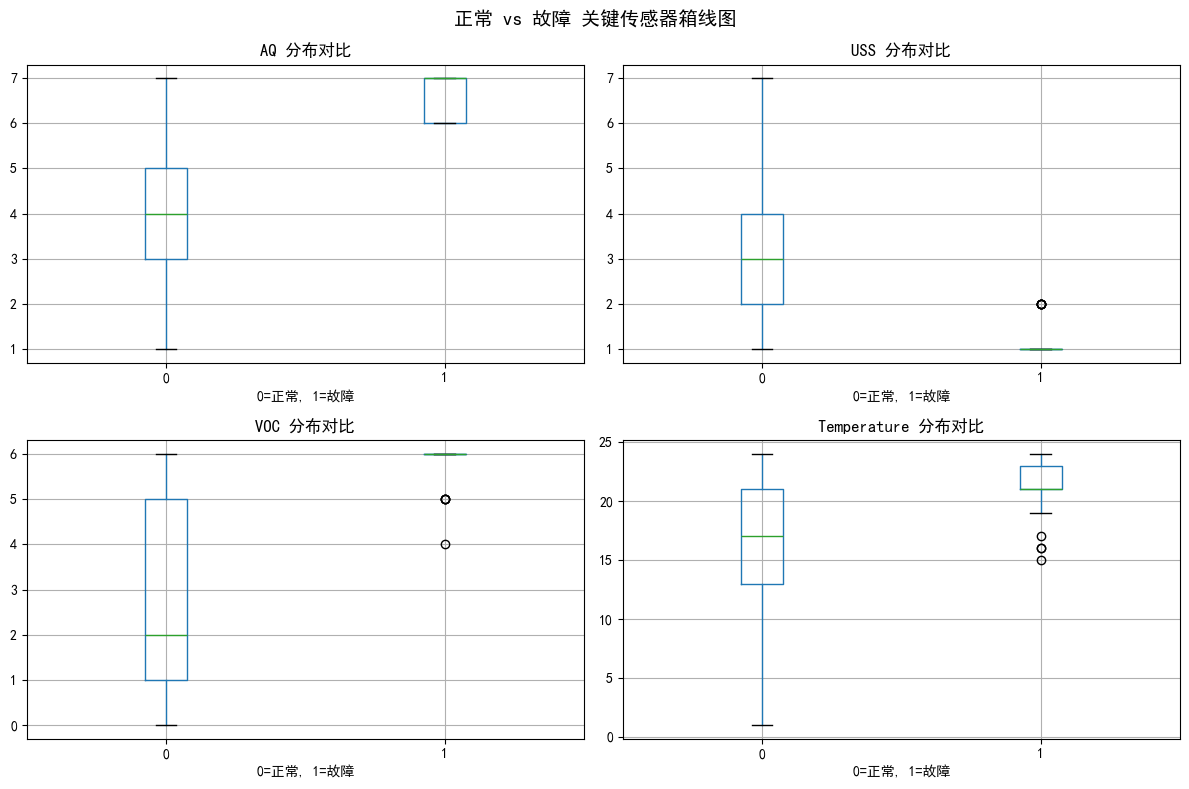

In [7]:
""" EDA——看正常 vs 故障传感器差异 """
feature_cols = ['footfall', 'tempMode', 'AQ', 'USS', 'CS', 'VOC', 'RP', 'IP', 'Temperature']

# 按 fail 分组，对比各传感器均值
print("=== 正常 vs 故障 各特征均值对比 ===")
print(df.groupby('fail')[feature_cols].mean().round(2))

# 画箱线图，选出四个最有区分度的传感器
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flatten(), ['AQ', 'USS', 'VOC', 'Temperature']):
    df.boxplot(column=col, by='fail', ax=ax)
    ax.set_title(f"{col} 分布对比")
    ax.set_xlabel("0=正常, 1=故障")
plt.suptitle("正常 vs 故障 关键传感器箱线图", fontsize=14)
plt.tight_layout()
plt.show()

设备故障不是瞬间突变，传感器**一段时间内的波动**更能反映异常。用滑动窗口提取统计特征：均值、标准差、最大值、最小值。

In [ ]:
""" 滑动窗口特征工程 """
window_size = 10
df_win = df.copy()

for col in feature_cols:
    df_win[f"{col}_mean"] = df_win[col].rolling(window=window_size).mean()
    df_win[f"{col}_std"] = df_win[col].rolling(window=window_size).std()
    df_win[f"{col}_max"] = df_win[col].rolling(window=window_size).max()
    df_win[f"{col}_min"] = df_win[col].rolling(window=window_size).min()

# rolling 前 window_size-1 行会产生 NaN，直接丢弃
df_win = df_win.dropna()
print(f"\n滑动窗口处理后 shape: {df_win.shape}")
print(f"特征列数: {len(df_win.columns) - 1}") # -1 是减去标签 fail


滑动窗口处理后 shape: (991, 46)
特征列数: 45


为模拟无监督异常检测真实场景，**训练集只能使用正常样本 (fail=0)**，模型学习正常设备行为模式；测试集混合正常 + 故障，用来检测异常。

In [9]:
""" 数据集划分 """
X_all = df_win.drop('fail', axis=1)
y_all = df_win['fail']

# 训练集（只取正常样本）
X_train = X_all[y_all == 0].copy()
y_train = y_all[y_all == 0].copy()

# 测试集（全部样本）
X_test = X_all.copy()
y_test = y_all.copy()

print(f"训练集: {X_train.shape}")
print(f"测试集: {X_test.shape}")
print(f"测试集中故障样本数: {(y_test == 1).sum()}")

训练集: (961, 45)
测试集: (991, 45)
测试集中故障样本数: 30


In [10]:
""" 标准化 """
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
""" 训练两个无监督异常检测模型 """
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM

iso = IsolationForest(
    contamination=0.03, # 估计异常占比，设为0.03（和数据真实故障占比一致）
    random_state=42,
    n_estimators=100
)
iso.fit(X_train_scaled)

ocsvm = OneClassSVM(
    nu=0.03, # 异常点上界比列，设为 0.03
    kernel='rbf',
    gamma='scale'
)
ocsvm.fit(X_train_scaled)

# sklearn 无监督输出：-1=异常，1=正常 → 映射为 1=故障，0=正常
def trans_label(y_pred):
    return np.where(y_pred == -1, 1, 0)

y_pred_iso = trans_label(iso.predict(X_test_scaled))
y_pred_ocsvm = trans_label(ocsvm.predict(X_test_scaled))

In [13]:
""" 评估 """
from sklearn.metrics import recall_score, precision_score, f1_score, confusion_matrix

def print_metrics(y_true, y_pred, name):
    rec = recall_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    cm = confusion_matrix(y_true, y_pred)

    print(f"\n===== {name} =====")
    print(f"召回率（故障检出率）: {rec:.4f}")
    print(f"精确率: {prec:.4f}")
    print(f"F1-score: {f1:.4f}")
    print(f"混淆矩阵:\n{cm}")
    print(f"  正常判对: {cm[0][0]}, 误报故障: {cm[0][1]}")
    print(f"  故障漏检: {cm[1][0]}, 故障检出: {cm[1][1]}")

print_metrics(y_test, y_pred_iso, "IsolationForest")
print_metrics(y_test, y_pred_ocsvm, "OneClassSVM")


===== IsolationForest =====
召回率（故障检出率）: 0.1000
精确率: 0.0938
F1-score: 0.0968
混淆矩阵:
[[932  29]
 [ 27   3]]
  正常判对: 932, 误报故障: 29
  故障漏检: 27, 故障检出: 3

===== OneClassSVM =====
召回率（故障检出率）: 0.1000
精确率: 0.0469
F1-score: 0.0638
混淆矩阵:
[[900  61]
 [ 27   3]]
  正常判对: 900, 误报故障: 61
  故障漏检: 27, 故障检出: 3


效果很差：30 个故障只检测出 3 个。调整参数再试试看：

In [ ]:
""" IsolationForest """
# 测试不同 contamination 参数
for cont in [0.03, 0.05, 0.08, 0.10, 0.15]:
    iso = IsolationForest(contamination=cont, random_state=42, n_estimators=200)
    iso.fit(X_train_scaled)

    y_pred = np.where(iso.predict(X_test_scaled) == -1, 1, 0)
    rec = recall_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    
    print(f"contamination={cont:.2f} | Recall={rec:.4f} | Precision={prec:.4f} | F1={f1:.4f}")

contamination=0.03 | Recall=0.0667 | Precision=0.0645 | F1=0.0656
contamination=0.05 | Recall=0.1000 | Precision=0.0588 | F1=0.0741
contamination=0.08 | Recall=0.1333 | Precision=0.0494 | F1=0.0721
contamination=0.10 | Recall=0.1667 | Precision=0.0495 | F1=0.0763
contamination=0.15 | Recall=0.2333 | Precision=0.0464 | F1=0.0773


In [15]:
""" OneClassSVM """
# 测试不同 nu
for nu in [0.03, 0.05, 0.08, 0.10, 0.15]:
    ocsvm = OneClassSVM(nu=nu, kernel="rbf", gamma="scale")
    ocsvm.fit(X_train_scaled)

    y_pred = np.where(ocsvm.predict(X_test_scaled) == -1, 1, 0)
    rec = recall_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    print(f"nu={nu:.2f} | Recall={rec:.4f} | Precision={prec:.4f} | F1={f1:.4f}")

nu=0.03 | Recall=0.1000 | Precision=0.0469 | F1=0.0638
nu=0.05 | Recall=0.1333 | Precision=0.0714 | F1=0.0930
nu=0.08 | Recall=0.1333 | Precision=0.0440 | F1=0.0661
nu=0.10 | Recall=0.1667 | Precision=0.0463 | F1=0.0725
nu=0.15 | Recall=0.1667 | Precision=0.0340 | F1=0.0565


In [16]:
""" 用原始特征，不做滑动窗口，重新跑 """
X_raw = df.drop("fail", axis=1)
y_raw = df["fail"]

X_train_raw = X_raw[y_raw == 0].copy()
X_test_raw = X_raw.copy()

scaler_raw = StandardScaler()
X_train_raw_scaled = scaler_raw.fit_transform(X_train_raw)
X_test_raw_scaled = scaler_raw.transform(X_test_raw)

for cont in [0.03, 0.05, 0.08, 0.10, 0.15]:
    iso = IsolationForest(contamination=cont, random_state=42, n_estimators=200)
    iso.fit(X_train_raw_scaled)

    y_pred = np.where(iso.predict(X_test_raw_scaled) == -1, 1, 0)
    rec = recall_score(y_raw, y_pred)
    prec = precision_score(y_raw, y_pred, zero_division=0)
    f1 = f1_score(y_raw, y_pred, zero_division=0)

    print(f"contamination={cont:.2f} | Recall={rec:.4f} | Precision={prec:.4f} | F1={f1:.4f}")

contamination=0.03 | Recall=0.0000 | Precision=0.0000 | F1=0.0000
contamination=0.05 | Recall=0.0000 | Precision=0.0000 | F1=0.0000
contamination=0.08 | Recall=0.0667 | Precision=0.0250 | F1=0.0364
contamination=0.10 | Recall=0.1000 | Precision=0.0300 | F1=0.0462
contamination=0.15 | Recall=0.1667 | Precision=0.0331 | F1=0.0552


| 实验             | 最优参数        | 最优 Recall  | 最优 F1      |
| ---------------------- | ------------------ | ---------- | ---------- |
| 滑动窗口 + IsolationForest | contamination=0.15 | **23.33%** | 0.0773     |
| 滑动窗口 + OneClassSVM     | nu=0.05            | 13.33%     | **0.0930** |
| 原始特征 + IsolationForest | contamination=0.15 | 16.67%     | 0.0552     |

## 发现

1. **滑动窗口特征 > 原始特征**：滑动窗口在这个数据集上确实有帮助，故障信号被窗口统计量放大了；
2. **contamination/nu 越大 → Recall 越高、Precision 越低**：典型的召回率 - 精确率权衡，工业场景优先召回率；
3. **整体效果偏弱**：Recall 最高只有 23.3%，30 个故障最多检出 7 个。

### 效果偏弱的原因
 
这个数据集的故障样本和正常样本在特征空间**重叠度较高**：正常样本 AQ 最大也能到 7，故障样本 AQ 最小也能到 1，单靠无监督距离 / 密度方法难以完全区分。无监督异常检测的固有局限：**没有标签指导，只能假设 "异常 = 离群"，但工业故障不一定在所有传感器上都表现为极端离群值。**

In [17]:
""" 试试 LOF 局部离群因子 """
from sklearn.neighbors import LocalOutlierFactor

lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.05,
    novelty=True
)
lof.fit(X_train_scaled)
y_pred_lof = np.where(lof.predict(X_test_scaled) == -1, 1, 0)

print(f"Recall: {recall_score(y_test, y_pred_lof):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lof, zero_division=0):.4f}")
print(f"F1: {f1_score(y_test, y_pred_lof, zero_division=0):.4f}")
print(f"混淆矩阵:\n{confusion_matrix(y_test, y_pred_lof)}")

Recall: 0.0333
Precision: 0.0263
F1: 0.0294
混淆矩阵:
[[924  37]
 [ 29   1]]


PASS!

In [18]:
""" 用有监督逻辑回归来对比 """
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

X_sup = df_win.drop('fail', axis=1)
y_sup = df_win['fail']

X_train_sup, X_test_sup, y_train_sup, y_test_sup = train_test_split(
    X_sup, y_sup, test_size=0.3, random_state=42, stratify=y_sup
)

scaler_sup = StandardScaler()
X_train_sup_scaled = scaler_sup.fit_transform(X_train_sup)
X_test_sup_scaled = scaler_sup.transform(X_test_sup)

lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1_000,
    random_state=42
)
lr.fit(X_train_sup_scaled, y_train_sup)
y_pred_lr = lr.predict(X_test_sup_scaled)

print(f"Recall: {recall_score(y_test_sup, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test_sup, y_pred_lr, zero_division=0):.4f}")
print(f"F1: {f1_score(y_test_sup, y_pred_lr, zero_division=0):.4f}")
print(f"混淆矩阵:\n{confusion_matrix(y_test_sup, y_pred_lr)}")

Recall: 0.8889
Precision: 0.3810
F1: 0.5333
混淆矩阵:
[[276  13]
 [  1   8]]


# 模型结果汇总

## 无监督模型

| 模型              | 最优参数               | Recall（故障检出率） | Precision | F1         |
| --------------- | ------------------ | ------------- | --------- | ---------- |
| IsolationForest | contamination=0.15 | **23.33%**    | 4.64%     | 0.0773     |
| One‑Class‑SVM   | nu=0.05            | 13.33%        | **7.14%** | **0.0930** |
| LOF 局部离群因子      | n_neighbors=20     | 3.33%         | 2.63%     | 0.0294     |

## 有监督模型
| 模型        | Recall     | Precision | F1         |
| --------- | ---------- | --------- | ---------- |
| 逻辑回归（有监督） | **88.89%** | 38.10%    | **0.5333** |

## 核心实验结论

1. **有监督 >> 无监督**：逻辑回归 Recall 达 88.89%，远高于无监督最优的 23.33%。原因：有监督模型直接学习故障样本的特征模式，无监督只能假设 "异常 = 离群"，而工业故障不一定在所有传感器上表现为极端离群值。
2. **contamination/nu 参数权衡**：参数越大 → 标记越多异常 → Recall 上升、Precision 下降。工业场景优先 Recall（宁可误报不可漏检），但误报过多会增加运维成本，需要业务权衡。
3. **无监督效果受限的根本原因**：
   - 故障样本与正常样本在特征空间重叠度较高，单靠距离 / 密度难以区分；
   - 无监督没有标签指导，无法学习 "什么样的传感器组合代表故障"；
   - 数据量较小（1000 条），无监督方法在大数据量下表现更好。
4. **滑动窗口有效**：窗口统计量（均值、标准差）能捕捉传感器短期波动，比原始单点特征更能反映异常。

# 模型优缺点分析

| 模型              | 优点                 | 缺点                            |
| --------------- | ------------------ | ----------------------------- |
| IsolationForest | 训练快、对高维数据友好、不需要标准化 | 对重叠度高的数据效果差、contamination 需预设 |
| One‑Class‑SVM   | 理论严谨、核函数可适配非线性边界   | 训练慢 (O (n²))、对 nu 参数敏感、必须标准化  |
| LOF             | 基于局部密度，能识别局部异常     | 对高维数据效果差、计算量大、效果不稳定           |
| 逻辑回归（有监督）       | 效果好、可解释、训练快        | 需要故障标签、标注成本高                  |

## 项目局限性与改进方向

**局限性：**

1. 数据集较小（1000 条），无监督方法在大数据量下表现更稳定；
2. 故障样本与正常样本特征重叠度高，无监督难以区分；
3. 滑动窗口大小固定为 10，未做窗口大小调优实验。

**改进方向：**

1. **半监督学习**：用少量标注故障样本 + 大量无标注数据训练，兼顾标注成本和效果；
2. **主动学习**：模型主动挑选最有价值的样本请专家标注，用最少标注获得最大效果提升；
3. **时序模型**：用 LSTM/Autoencoder 等深度学习模型捕捉时序依赖，比滑动窗口统计更精细；
4. **多模型融合**：IsolationForest + OneClassSVM + LOF 投票，综合多个无监督模型的异常分数；
5. **特征工程优化**：调整滑动窗口大小、增加变化率特征（差分）、传感器交叉组合特征。